In [13]:
import os
import cv2
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset
from scipy.signal import butter, filtfilt

class MultiTaskRPPGDataset(Dataset):
    def __init__(self, csv_path, data_dir, patient_list=None, target_frames=600, fps=30.0):
        """
        Advanced Multi-Task Dataset with Real-time rPPG Signal Processing.
        """
        self.df = pd.read_csv(csv_path)
        self.data_dir = data_dir
        self.target_frames = target_frames
        self.fps = fps
        
        self.age_min, self.age_max = self.df['age'].min(), self.df['age'].max()
        self.bmi_min, self.bmi_max = self.df['bmi'].min(), self.df['bmi'].max()

        self.valid_rows = []
        for idx, row in self.df.iterrows():
            if patient_list is not None and row['patient_id'] not in patient_list:
                continue
            video_path = os.path.join(self.data_dir, str(row['video']))
            if os.path.exists(video_path):
                self.valid_rows.append(row)
                
        print(f"📦 Dataset Split initialized with {len(self.valid_rows)} valid samples.")

    def __len__(self):
        return len(self.valid_rows)

    def _butter_bandpass_filter(self, data, lowcut=0.75, highcut=4.0, order=3):
        """Applies a zero-phase Butterworth bandpass filter to remove optical noise."""
        nyq = 0.5 * self.fps
        low = lowcut / nyq
        high = highcut / nyq
        b, a = butter(order, [low, high], btype='bar')
        # filtfilt applies the filter forward and backward to prevent phase shifting
        return filtfilt(b, a, data)

    def _process_signal(self, rgb_array):
        """Detrends and normalizes the raw RGB sequences."""
        processed_channels = []
        for i in range(3):  # Process R, G, and B independently
            channel = rgb_array[:, i]
            
            # 1. Detrending: Remove the rolling baseline shift
            # Subtracting the moving average keeps the signal centered at 0
            window_len = int(self.fps * 2) # 2-second rolling window
            if len(channel) > window_len:
                rolling_mean = np.convolve(channel, np.ones(window_len)/window_len, mode='same')
                channel = channel - rolling_mean
            
            # 2. Bandpass Filter: Keep only human cardiac frequencies
            try:
                channel = self._butter_bandpass_filter(channel)
            except Exception:
                pass # Fallback if signal sequence is too short for full order filtering
                
            # 3. Z-score Normalization: Scale variance so amplitude differences don't break the CNN
            std = np.std(channel)
            if std > 1e-6:
                channel = (channel - np.mean(channel)) / std
                
            processed_channels.append(channel)
            
        return np.array(processed_channels, dtype=np.float32)

    def _extract_rgb_trace(self, video_path):
        cap = cv2.VideoCapture(video_path)
        rgb_traces = []
        frame_count = 0
        
        while cap.isOpened() and frame_count < self.target_frames:
            ret, frame = cap.read()
            if not ret:
                break
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            h, w, _ = frame_rgb.shape
            
            top, bottom = int(h * 0.3), int(h * 0.7)
            left, right = int(w * 0.3), int(w * 0.7)
            roi = frame_rgb[top:bottom, left:right]
            
            mean_val = cv2.mean(roi)[:3]
            rgb_traces.append(mean_val)
            frame_count += 1
            
        cap.release()
        
        if len(rgb_traces) == 0:
            rgb_traces = [[0.0, 0.0, 0.0]]
        while len(rgb_traces) < self.target_frames:
            rgb_traces.append(rgb_traces[-1])
            
        raw_signal = np.array(rgb_traces, dtype=np.float32)
        
        # 🔥 Clean the raw optical signals before returning them as a tensor
        clean_signal = self._process_signal(raw_signal)
        return clean_signal  # Already outputting shape (3, 600) due to transposing inside _process_signal

    def __getitem__(self, idx):
        row = self.valid_rows[idx]
        
        video_full_path = os.path.join(self.data_dir, row['video'])
        x_signal_tensor = torch.from_numpy(self._extract_rgb_trace(video_full_path))
        
        norm_age = (float(row['age']) - self.age_min) / (self.age_max - self.age_min + 1e-5)
        norm_bmi = (float(row['bmi']) - self.bmi_min) / (self.bmi_max - self.bmi_min + 1e-5)
        is_male = 1.0 if str(row['sex']).strip().upper() == 'M' else 0.0
        
        step_str = str(row['step']).strip().lower()
        is_before = 1.0 if step_str == 'before' else 0.0
        is_after  = 1.0 if step_str == 'after' else 0.0
        is_rest   = 1.0 if step_str == 'rest' else 0.0
        
        x_context = [norm_age, norm_bmi, is_male, is_before, is_after, is_rest]
        x_context_tensor = torch.tensor(x_context, dtype=torch.float32)
        
        targets = {
            'pulse': torch.tensor(float(row['pulse']), dtype=torch.float32),
            'saturation': torch.tensor(float(row['saturation']), dtype=torch.float32),
            'upper_ap': torch.tensor(float(row['upper_ap']), dtype=torch.float32),
            'lower_ap': torch.tensor(float(row['lower_ap']), dtype=torch.float32),
            'glycated_hemoglobin': torch.tensor(float(row['glycated_hemoglobin']), dtype=torch.float32),
            'hemoglobin': torch.tensor(float(row['hemoglobin']), dtype=torch.float32),
            'cholesterol': torch.tensor(float(row['cholesterol']), dtype=torch.float32),
            'temperature': torch.tensor(float(row['temperature']), dtype=torch.float32),
            'respiratory': torch.tensor(float(row['respiratory']), dtype=torch.float32)
        }
        
        return x_signal_tensor, x_context_tensor, targets

In [17]:
import torch
import torch.nn as nn

class DeeperMultiTaskRPPGNet(nn.Module):
    def __init__(self, context_dim=6):
        super(DeeperMultiTaskRPPGNet, self).__init__()
        
        # 1. EXPANDED SIGNAL BACKBONE: Deeper layer hierarchy for intricate wave dynamics
        self.feature_extractor = nn.Sequential(
            nn.Conv1d(in_channels=3, out_channels=16, kernel_size=15, stride=2, padding=7),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2),
            
            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=9, stride=2, padding=4),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)  # Compresses down to (Batch, 128, 1) -> (Batch, 128)
        )
        
        # 2. FEATURE FUSION LAYER
        combined_dim = 128 + context_dim
        
        self.shared_dense = nn.Sequential(
            nn.Linear(combined_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),  # Slightly higher dropout to counter over-memorization
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        
        # 3. SPECIALIZED REGRESSION HEADS
        self.head_pulse               = nn.Linear(128, 1)
        self.head_saturation          = nn.Linear(128, 1)
        self.head_upper_ap            = nn.Linear(128, 1)
        self.head_lower_ap            = nn.Linear(128, 1)
        self.head_glycated_hemoglobin = nn.Linear(128, 1)
        self.head_hemoglobin          = nn.Linear(128, 1)
        self.head_cholesterol         = nn.Linear(128, 1)
        self.head_temperature         = nn.Linear(128, 1)
        self.head_respiratory         = nn.Linear(128, 1)

    def forward(self, signal, context):
        features = self.feature_extractor(signal)
        features = features.view(features.size(0), -1)  # Flatten to (Batch, 128)
        
        fused = torch.cat((features, context), dim=1)
        shared_out = self.shared_dense(fused)
        
        output_dict = {
            'pulse': self.head_pulse(shared_out).squeeze(-1),
            'saturation': self.head_saturation(shared_out).squeeze(-1),
            'upper_ap': self.head_upper_ap(shared_out).squeeze(-1),
            'lower_ap': self.head_lower_ap(shared_out).squeeze(-1),
            'glycated_hemoglobin': self.head_glycated_hemoglobin(shared_out).squeeze(-1),
            'hemoglobin': self.head_hemoglobin(shared_out).squeeze(-1),
            'cholesterol': self.head_cholesterol(shared_out).squeeze(-1),
            'temperature': self.head_temperature(shared_out).squeeze(-1),
            'respiratory': self.head_respiratory(shared_out).squeeze(-1)
        }
        return output_dict

print("✅ Deeper Multi-Task Architecture ready.")

✅ Deeper Multi-Task Architecture ready.


In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd

# Load structural split
df_master = pd.read_csv(csv_file)
unique_patients = df_master['patient_id'].unique()
np.random.seed(42)
np.random.shuffle(unique_patients)

split_idx = int(len(unique_patients) * 0.8)
train_pts = unique_patients[:split_idx]
val_pts = unique_patients[split_idx:]

train_dataset = MultiTaskRPPGDataset(csv_path=csv_file, data_dir=data_directory, patient_list=train_pts)
val_dataset = MultiTaskRPPGDataset(csv_path=csv_file, data_dir=data_directory, patient_list=val_pts)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)  # Increased batch size slightly
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DeeperMultiTaskRPPGNet(context_dim=6).to(device)

# Adjusted Base Learning Rate & Introduced L2 Regularization (weight_decay)
optimizer = optim.AdamW(model.parameters(), lr=0.002, weight_decay=0.02)

# Cosine Annealing scheduler over 20 epochs
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-5)
criterion = nn.MSELoss()

# Fine-tuned loss weight balances
loss_weights = {
    'pulse': 0.1,         # Slightly increased emphasis
    'saturation': 1.0,
    'upper_ap': 0.1,     # Slightly increased emphasis
    'lower_ap': 0.1,
    'glycated_hemoglobin': 1.0,
    'hemoglobin': 0.5,
    'cholesterol': 0.5,
    'temperature': 1.0,
    'respiratory': 0.5
}

num_epochs = 20
print(f"\n🚀 Launching Advanced Optimization Loop (20 Epochs) on: {device}")
print("="*75)

for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0
    for signals, contexts, targets in train_loader:
        signals, contexts = signals.to(device), contexts.to(device)
        optimizer.zero_grad()
        predictions = model(signals, contexts)
        
        total_loss = 0.0
        for name in loss_weights.keys():
            raw_loss = criterion(predictions[name], targets[name].to(device))
            total_loss += loss_weights[name] * raw_loss
            
        total_loss.backward()
        optimizer.step()
        running_train_loss += total_loss.item()
        
    # Validation
    model.eval()
    running_val_loss = 0.0
    val_head_losses = {key: 0.0 for key in loss_weights.keys()}
    
    with torch.no_grad():
        for signals, contexts, targets in val_loader:
            signals, contexts = signals.to(device), contexts.to(device)
            predictions = model(signals, contexts)
            
            total_loss = 0.0
            for name in loss_weights.keys():
                raw_loss = criterion(predictions[name], targets[name].to(device))
                val_head_losses[name] += raw_loss.item()
                total_loss += loss_weights[name] * raw_loss
            running_val_loss += total_loss.item()
            
    # Advance Learning Rate Decay Step
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    epoch_train = running_train_loss / len(train_loader)
    epoch_val = running_val_loss / len(val_loader)
    
    # Print status updates every 4 epochs to keep terminal clean, always printing epoch 1 and 20
    if (epoch + 1) == 1 or (epoch + 1) == 20 or (epoch + 1) % 4 == 0:
        print(f"📈 Epoch [{epoch+1}/{num_epochs}] | LR: {current_lr:.5f} | Train Loss: {epoch_train:.4f} | True Val Loss: {epoch_val:.4f}")
        print("   ↳ Unweighted Validation Errors Breakdown (MSE):")
        for name in loss_weights.keys():
            avg_val_error = val_head_losses[name] / len(val_loader)
            print(f"     • {name.ljust(20)}: {avg_val_error:.3f}")
        print("-"*75)

print("\n🎉 Extended multi-task optimization run successfully complete!")

📦 Dataset Split initialized with 240 valid samples.
📦 Dataset Split initialized with 60 valid samples.

🚀 Launching Advanced Optimization Loop (20 Epochs) on: cpu
📈 Epoch [1/20] | LR: 0.00199 | Train Loss: 8389.1013 | True Val Loss: 3047.3208
   ↳ Unweighted Validation Errors Breakdown (MSE):
     • pulse               : 502.877
     • saturation          : 1662.144
     • upper_ap            : 342.568
     • lower_ap            : 512.502
     • glycated_hemoglobin : 3.174
     • hemoglobin          : 158.972
     • cholesterol         : 36.277
     • temperature         : 991.436
     • respiratory         : 314.295
---------------------------------------------------------------------------
📈 Epoch [4/20] | LR: 0.00181 | Train Loss: 232.2099 | True Val Loss: 86.2102
   ↳ Unweighted Validation Errors Breakdown (MSE):
     • pulse               : 454.856
     • saturation          : 3.876
     • upper_ap            : 266.759
     • lower_ap            : 46.654
     • glycated_hemoglobin

Matplotlib is building the font cache; this may take a moment.



📊 Patient sample 1 Comparison Profile:
--------------------------------------------------
Biomarker                 |   True Value | AI Predicted
--------------------------------------------------
pulse                     |        88.00 |        94.46
saturation                |        99.00 |       101.08
upper_ap                  |       115.00 |       126.37
lower_ap                  |        69.00 |        75.34
glycated_hemoglobin       |         5.83 |         5.84
hemoglobin                |         9.30 |        14.08
cholesterol               |         5.00 |         4.09
temperature               |        36.60 |        37.64
respiratory               |        20.00 |        18.66

📊 Patient sample 2 Comparison Profile:
--------------------------------------------------
Biomarker                 |   True Value | AI Predicted
--------------------------------------------------
pulse                     |        88.00 |        93.20
saturation                |        99.00 |  

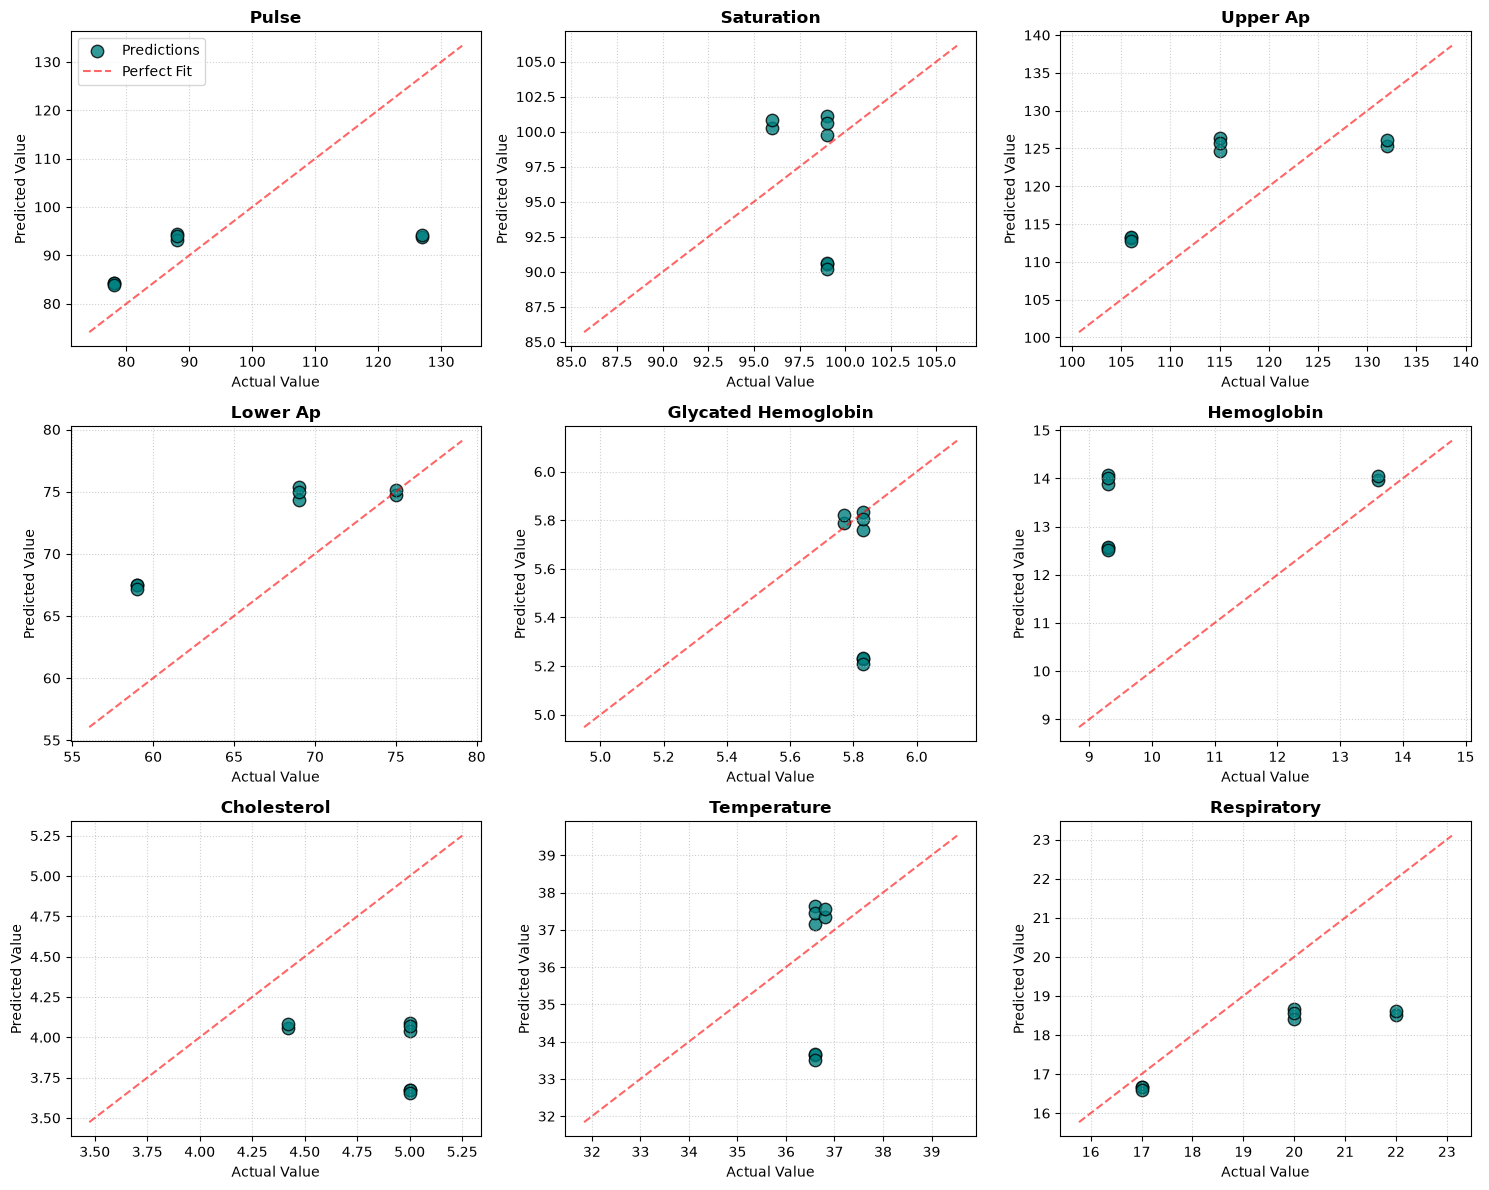

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch

# 1. Gather a sample batch from the validation loader
model.eval()
sample_signals, sample_contexts, sample_targets = next(iter(val_loader))

# Move data to the active processing hardware
sample_signals = sample_signals.to(device)
sample_contexts = sample_contexts.to(device)

# 2. Run inference to gather AI predictions
with torch.no_grad():
    predictions = model(sample_signals, sample_contexts)

# 3. Format metrics into a clean, readable comparison table
comparison_data = []
biomarkers = list(loss_weights.keys())

# We will look at the first 3 patients in the validation batch
for patient_idx in range(min(3, len(sample_signals))):
    print(f"\n📊 Patient sample {patient_idx + 1} Comparison Profile:")
    print("-" * 50)
    print(f"{'Biomarker'.ljust(25)} | {'True Value'.rjust(12)} | {'AI Predicted'.rjust(12)}")
    print("-" * 50)
    
    for marker in biomarkers:
        true_val = sample_targets[marker][patient_idx].item()
        pred_val = predictions[marker][patient_idx].item()
        print(f"{marker.ljust(25)} | {true_val:12.2f} | {pred_val:12.2f}")
    print("=" * 50)

# 4. Generate a multi-plot visualization chart
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, marker in enumerate(biomarkers):
    true_vals = sample_targets[marker].numpy()
    pred_vals = predictions[marker].cpu().numpy()
    
    ax = axes[idx]
    # Plot true values vs predictions as a scatter plot
    ax.scatter(true_vals, pred_vals, color='teal', edgecolors='k', s=80, alpha=0.8, label='Predictions')
    
    # Draw a perfect matching reference line (y = x)
    min_val = min(true_vals.min(), pred_vals.min()) * 0.95
    max_val = max(true_vals.max(), pred_vals.max()) * 1.05
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.6, label='Perfect Fit')
    
    ax.set_title(f'{marker.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Actual Value')
    ax.set_ylabel('Predicted Value')
    ax.grid(True, linestyle=':', alpha=0.6)
    if idx == 0:
        ax.legend()

plt.tight_layout()
plt.show()